In [111]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples

In [112]:
raw_df = pd.read_csv("online_retail_II.csv")

In [113]:
raw_df.head(100)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
95,489441,22111,SCOTTIE DOG HOT WATER BOTTLE,48,2009-12-01 09:44:00,4.25,18087.0,United Kingdom
96,489442,21955,UNION JACK GUNS & ROSES DOORMAT,2,2009-12-01 09:46:00,6.75,13635.0,United Kingdom
97,489442,22111,SCOTTIE DOG HOT WATER BOTTLE,3,2009-12-01 09:46:00,4.95,13635.0,United Kingdom
98,489442,22296,HEART IVORY TRELLIS LARGE,12,2009-12-01 09:46:00,1.65,13635.0,United Kingdom


In [114]:
raw_df.shape

(1067371, 8)

In [115]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [116]:
raw_df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [117]:
raw_df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [118]:
#data cleaning
def clean_data(df):
    # Drop rows without Customer ID
    df = df.dropna(subset=['Customer ID'])
    
    # Remove Cancellations (Invoices starting with 'C')
    df = df[~df['Invoice'].str.contains('C', na=False)]
    
    # Ensure Quantity and Price are positive
    df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
    
    # Create TotalPrice feature
    df['TotalSum'] = df['Quantity'] * df['Price']
    
    # Convert InvoiceDate to datetime
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    
    return df

df_clean = clean_data(raw_df)

In [139]:
# Select important columns
selected_columns = df_clean[['Customer ID',
                             'Invoice',
                             'InvoiceDate',
                             'Quantity',
                             'Price']].copy()

# Show only the date (remove time)
selected_columns['InvoiceDate'] = selected_columns['InvoiceDate'].dt.date

# Display first 10 rows
selected_columns.head(10)

,Customer ID,Invoice,InvoiceDate,Quantity,Price
0,13085.0,489434,2009-12-01,12,6.95
1,13085.0,489434,2009-12-01,12,6.75
2,13085.0,489434,2009-12-01,12,6.75
3,13085.0,489434,2009-12-01,48,2.10
4,13085.0,489434,2009-12-01,24,1.25
5,13085.0,489434,2009-12-01,24,1.65
6,13085.0,489434,2009-12-01,24,1.25
7,13085.0,489434,2009-12-01,10,5.95
8,13085.0,489435,2009-12-01,12,2.55
9,13085.0,489435,2009-12-01,12,3.75


In [119]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSum
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [120]:
df_clean.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalSum       0
dtype: int64

In [121]:
df_clean.shape

(805549, 9)

In [122]:
# I created a reference date for 'Recency' (one day after the last transaction)
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
# I created the RFM table 
rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'Invoice': 'nunique',                                   # Frequency
    'TotalSum': 'sum'                                       # Monetary
})
#rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [123]:
rfm.head(7)

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40
12351.0,375,1,300.93
12352.0,36,10,2849.84


In [124]:
#Removal of Outliers (IQR Method)
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.05)
        Q3 = df[col].quantile(0.95)
        IQR = Q3 - Q1
        df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]
    return df

rfm_clean = remove_outliers(rfm, ['Recency', 'Frequency', 'Monetary'])

In [125]:
#Data Transformation and Normalization
#Log Transform to handle skewness
rfm_log = np.log1p(rfm_clean)

#Standardization
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm_clean.index, columns=rfm_clean.columns)

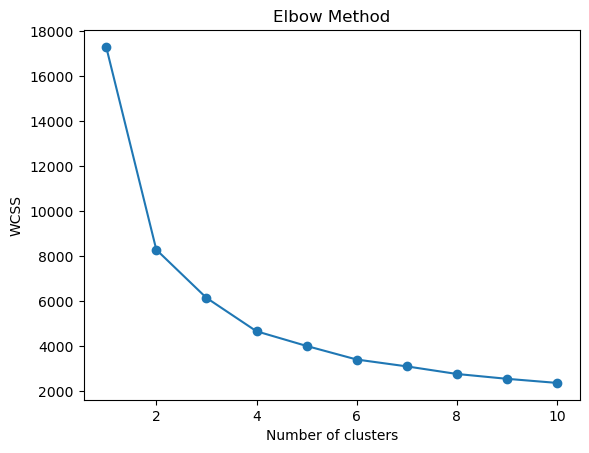

In [126]:
#Finding Optimal K (The Elbow Method)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [127]:
#Applying K-Means (k=4 based on Elbow)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
rfm_clean['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

In [128]:
rfm_clean['Cluster'].value_counts()

Cluster
3    1856
1    1455
2    1273
0    1187
Name: count, dtype: int64

In [129]:
# silhouette score
sil_score = silhouette_score(rfm_scaled_df, rfm_clean['Cluster'])
print("Silhouette Score:", round(sil_score, 3))

Silhouette Score: 0.37


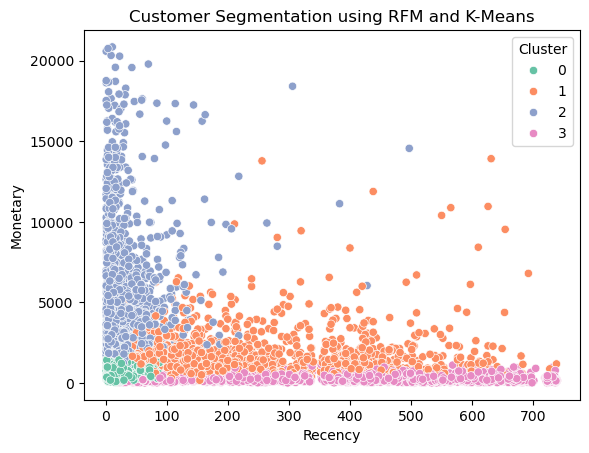

In [130]:
sns.scatterplot(
    x=rfm_clean['Recency'],
    y=rfm_clean['Monetary'],
    hue=rfm_clean['Cluster'],
    palette='Set2'
)
plt.title('Customer Segmentation using RFM and K-Means')
plt.show()

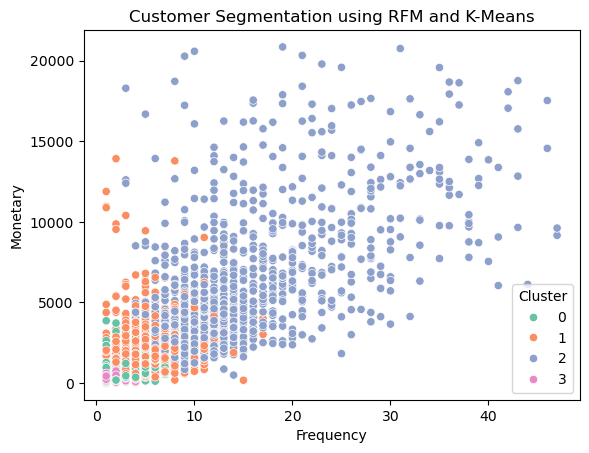

In [131]:
sns.scatterplot(
    x=rfm_clean['Frequency'],
    y=rfm_clean['Monetary'],
    hue=rfm_clean['Cluster'],
    palette='Set2'
)
plt.title('Customer Segmentation using RFM and K-Means')
plt.show()

In [132]:
#Authentic Analysis: Cluster Profiling ---
analysis = rfm_clean.groupby('Cluster').agg({
    'Recency': ['mean', 'min', 'max'],
    'Frequency': ['mean', 'count'],
    'Monetary': ['mean']
}).round(1)

In [133]:
print(analysis)

        Recency          Frequency       Monetary
           mean min  max      mean count     mean
Cluster                                          
0          29.9   1  106       2.8  1187    790.0
1         247.4  35  738       4.6  1455   1709.7
2          30.8   1  497      13.8  1273   5527.2
3         400.9  23  739       1.3  1856    302.0


In [134]:
segment_summary = rfm_clean.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

print(segment_summary)

         Recency  Frequency  Monetary
Cluster                              
0          29.90       2.82    789.95
1         247.36       4.61   1709.67
2          30.84      13.83   5527.20
3         400.90       1.32    302.04


In [135]:
# Define cluster meanings
cluster_mapping = {
    0: 'Recently Acquired Customers',
    1: 'Customers Likely to Churn',
    2: 'Most Valuable Customers',
    3: 'Least Engaged Customers'
}
sample_customers = (
    rfm_clean.groupby('Cluster', group_keys=False)
    .apply(lambda x: x.sample(7, random_state=42))
)
# Reset index
sample_customers = sample_customers.reset_index(names='Customer ID')
# Add customer segment names
sample_customers['Customer Segment'] = (
    sample_customers['Cluster'].map(cluster_mapping)
)
print(sample_customers[
    ['Customer ID',
     'Cluster',
     'Recency',
     'Frequency',
     'Monetary']
])

    Customer ID  Cluster  Recency  Frequency  Monetary
0       13962.0        0       22          3    362.80
1       17159.0        0       22          5   2099.59
2       17839.0        0       42          1    338.80
3       12723.0        0        4          5    725.07
4       17357.0        0       24          2    388.14
5       14731.0        0       47          3    380.02
6       17527.0        0       54          4    939.37
7       14256.0        1      260          5   2473.99
8       17356.0        1      312          5    946.47
9       13920.0        1      432          4   1774.68
10      16472.0        1      434          2    789.60
11      16421.0        1      376          3    526.27
12      14699.0        1      214          4    702.60
13      13224.0        1       60          2   2155.95
14      12490.0        2        5         21   9823.64
15      17696.0        2       38         27   7679.59
16      12867.0        2       26         13   7913.29
17      18

C:\Users\DELL\AppData\Local\Temp\ipykernel_15200\3845645571.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(7, random_state=42))


In [136]:
sample_customers.to_csv(
    'sample_customers_per_cluster.csv',
    index=False
)

In [137]:
print(rfm_clean.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean())

            Recency  Frequency     Monetary
Cluster                                    
0         29.901432   2.816344   789.953211
1        247.360825   4.613058  1709.673304
2         30.840534  13.834250  5527.195299
3        400.903556   1.318966   302.038519


In [ ]:
sample_customers_per_cluster.csv